# Ridge / Random Forest Forecasting Models

This notebook trains tabular Ridge and Random Forest baselines under the shared PowerNap evaluation contract. Official results use chronological and leave-one-region-out splits; random splits are intentionally excluded from the official comparison.


In [ ]:
# import modules
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

#set parameters
TARGET_COL = "carbon_intensity"
UNIT = "gCO2eq/kWh"
HORIZONS = [1, 6, 24]
REGIONS = ["california", "illinois", "texas", "virginia"]
TRAIN_FRAC = 0.70
VAL_FRAC = 0.10
VAL_END_FRAC = TRAIN_FRAC + VAL_FRAC
RANDOM_STATE = 42
PREDICTION_DIR = Path("model_predictions")
PREDICTION_DIR.mkdir(exist_ok=True)

#set features
REQUIRED_PREDICTION_COLUMNS = [
    "datetime", "target_datetime", "region", "horizon", "model",
    "y_true", "y_pred", "split_type", "split", "holdout_region",
]

base_features = [
    "temp_c", "wind_speed", "cloud_cover", "solar_radiation",
    "carbon_intensity_lag_1", "carbon_intensity_lag_2",
    "carbon_intensity_lag_3", "carbon_intensity_lag_24",
    "hour_sin", "hour_cos",
    "day_of_week_sin", "day_of_week_cos",
    "month_sin", "month_cos",
    "cfe_pct", "re_pct",
]


## Load Featured Dataset

The dataset already contains weather, energy mix, lag features, and cyclical time encodings. Ridge/RF use one tabular row at prediction time `t` rather than a 24-hour sequence.


In [ ]:
#load dataset
df = pd.read_csv("full_dataset_featured.csv", parse_dates=["datetime"])
df = df.sort_values(["region", "datetime"]).reset_index(drop=True)

missing = sorted(set(["datetime", "region", TARGET_COL] + base_features) - set(df.columns))
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Shape:", df.shape)
print("Date range:", df["datetime"].min(), "to", df["datetime"].max())
print("Regions:", sorted(df["region"].unique()))
display(df.head())


Shape: (34944, 22)
Date range: 2023-01-02 00:00:00 to 2023-12-31 23:00:00
Regions: ['california', 'illinois', 'texas', 'virginia']


,datetime,carbon_intensity,cfe_pct,re_pct,region,temp_c,wind_speed,cloud_cover,solar_radiation,hour,...,carbon_intensity_lag_1,carbon_intensity_lag_2,carbon_intensity_lag_3,carbon_intensity_lag_24,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos
0,2023-01-02 00:00:00,189.75,57.76,42.56,california,13.8,15.7,62,214.0,0,...,147.89,124.07,122.53,214.40,0.000000,1.000000,0.0,1.0,0.5,0.866025
1,2023-01-02 01:00:00,207.79,53.13,38.72,california,11.4,12.8,19,54.0,1,...,189.75,147.89,124.07,216.88,0.258819,0.965926,0.0,1.0,0.5,0.866025
2,2023-01-02 02:00:00,213.71,52.04,37.98,california,9.6,10.7,57,0.0,2,...,207.79,189.75,147.89,220.01,0.500000,0.866025,0.0,1.0,0.5,0.866025
3,2023-01-02 03:00:00,214.20,52.12,37.95,california,7.9,8.2,58,0.0,3,...,213.71,207.79,189.75,225.41,0.707107,0.707107,0.0,1.0,0.5,0.866025
4,2023-01-02 04:00:00,216.54,52.20,37.62,california,7.3,6.9,99,0.0,4,...,214.20,213.71,207.79,220.87,0.866025,0.500000,0.0,1.0,0.5,0.866025


## Shared Helpers

Targets are created per region so future labels never cross region boundaries. Chronological splits include a horizon-sized boundary gap so train labels do not land inside later validation or test periods.


In [ ]:
#chronological forecast frame
def make_forecast_frame(data, horizon):
    frame = data.sort_values(["region", "datetime"]).copy()
    grouped = frame.groupby("region", sort=False)
    frame["target_datetime"] = grouped["datetime"].shift(-horizon)
    frame["y_true"] = grouped[TARGET_COL].shift(-horizon)
    frame["horizon"] = int(horizon)
    return frame.dropna(subset=["target_datetime", "y_true"]).reset_index(drop=True)

#assigning chrono splits
def assign_chronological_splits(frame, horizon):
    out = frame.sort_values(["region", "datetime"]).copy()
    out["split"] = "unused_gap"

    for _, idx in out.groupby("region", sort=False).groups.items():
        idx = list(idx)
        n = len(idx)
        train_boundary = int(n * TRAIN_FRAC)
        val_boundary = int(n * VAL_END_FRAC)
        train_end = max(train_boundary - horizon, 0)
        val_end = max(val_boundary - horizon, train_boundary)

        values = np.array(["unused_gap"] * n, dtype=object)
        positions = np.arange(n)
        values[positions < train_end] = "train"
        values[(positions >= train_boundary) & (positions < val_end)] = "val"
        values[positions >= val_boundary] = "test"
        out.loc[idx, "split"] = values

    return out.reset_index(drop=True)

#model building method
def build_model(model_name):
    if model_name == "ridge":
        return make_pipeline(StandardScaler(), Ridge())
    if model_name == "random_forest":
        return RandomForestRegressor(
            n_estimators=50,
            max_depth=8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    raise ValueError(f"Unknown model: {model_name}")

#organizing metrics into a single row
def metric_row(y_true, y_pred):
    residual = np.asarray(y_pred) - np.asarray(y_true)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Bias": float(np.mean(residual)),
    }

#organizing predictions
def prediction_rows(test_frame, y_pred, model_name, split_type, split, holdout_region="none"):
    out = test_frame[["datetime", "target_datetime", "region", "horizon", "y_true"]].copy()
    out["model"] = model_name
    out["y_pred"] = np.asarray(y_pred)
    out["split_type"] = split_type
    out["split"] = split
    out["holdout_region"] = holdout_region
    return out[REQUIRED_PREDICTION_COLUMNS]

#packaging model methods
def fit_predict(train_frame, test_frame, model_name):
    model = build_model(model_name)
    model.fit(train_frame[base_features], train_frame["y_true"])
    return model, model.predict(test_frame[base_features])

#summarizing predictions
def summarize_predictions(predictions):
    rows = []
    group_cols = ["split_type", "model", "horizon", "region"]
    for keys, group in predictions.groupby(group_cols):
        row = dict(zip(group_cols, keys))
        row["n"] = len(group)
        row.update(metric_row(group["y_true"], group["y_pred"]))
        rows.append(row)
    metrics = pd.DataFrame(rows)

    macro_rows = []
    for keys, group in metrics.groupby(["split_type", "model", "horizon"]):
        row = dict(zip(["split_type", "model", "horizon"], keys))
        row["region"] = "macro_average"
        row["n"] = group["n"].sum()
        for col in ["MAE", "RMSE", "R2", "Bias"]:
            row[col] = group[col].mean()
        macro_rows.append(row)

    return pd.concat([metrics, pd.DataFrame(macro_rows)], ignore_index=True)


## Temporal Generalization: Regional Ridge/RF Models

Each region gets its own Ridge/RF model. This matches the planned regional LSTM comparison: train on earlier time periods for the same region, test on later time periods for that region.


In [ ]:
all_predictions = []
trained_models = {}

#loop training each chronological model, across each region and each forecasting horizon
for horizon in HORIZONS:
    frame = assign_chronological_splits(make_forecast_frame(df, horizon), horizon)

    for region in REGIONS:
        region_frame = frame[frame["region"] == region].copy()
        train_frame = region_frame[region_frame["split"] == "train"]
        test_frame = region_frame[region_frame["split"] == "test"]

        for model_name in ["ridge", "random_forest"]:
            model, preds = fit_predict(train_frame, test_frame, model_name)
            trained_models[("chronological_time", region, horizon, model_name)] = model
            all_predictions.append(
                prediction_rows(
                    test_frame,
                    preds,
                    model_name=model_name,
                    split_type="chronological_time",
                    split="test",
                    holdout_region="none",
                )
            )

print("Temporal prediction groups:", len(all_predictions))


Temporal prediction groups: 24


## Regional Generalization: Leave-One-Region-Out Ridge/RF Models

For each held-out region, train on the other three regions and test only on the unseen region. This matches the planned global LSTM comparison.


In [ ]:
#loop training each regional model, across each held-out region and each forecasting horizon
for horizon in HORIZONS:
    frame = make_forecast_frame(df, horizon)

    for holdout_region in REGIONS:
        train_frame = frame[frame["region"] != holdout_region].copy()
        test_frame = frame[frame["region"] == holdout_region].copy()

        for model_name in ["ridge", "random_forest"]:
            model, preds = fit_predict(train_frame, test_frame, model_name)
            trained_models[("leave_one_region_out", holdout_region, horizon, model_name)] = model
            all_predictions.append(
                prediction_rows(
                    test_frame,
                    preds,
                    model_name=model_name,
                    split_type="leave_one_region_out",
                    split=f"held_out_{holdout_region}",
                    holdout_region=holdout_region,
                )
            )

predictions_df = pd.concat(all_predictions, ignore_index=True)
predictions_df = predictions_df.sort_values(["split_type", "horizon", "model", "region", "datetime"])

output_path = PREDICTION_DIR / "ridge_rf_predictions.csv"
predictions_df.to_csv(output_path, index=False)
print(f"Saved {len(predictions_df):,} predictions to {output_path}")
display(predictions_df.head())


Saved 251,320 predictions to model_predictions/ridge_rf_predictions.csv


,datetime,target_datetime,region,horizon,model,y_true,y_pred,split_type,split,holdout_region
1748,2023-10-20 03:00:00,2023-10-20 04:00:00,california,1,random_forest,306.06,285.068423,chronological_time,test,none
1749,2023-10-20 04:00:00,2023-10-20 05:00:00,california,1,random_forest,309.64,285.151297,chronological_time,test,none
1750,2023-10-20 05:00:00,2023-10-20 06:00:00,california,1,random_forest,310.53,285.048717,chronological_time,test,none
1751,2023-10-20 06:00:00,2023-10-20 07:00:00,california,1,random_forest,311.47,285.626993,chronological_time,test,none
1752,2023-10-20 07:00:00,2023-10-20 08:00:00,california,1,random_forest,310.65,286.585880,chronological_time,test,none


## Ridge/RF Metrics

These are notebook-local diagnostics. The official cross-model comparison is done in `05_evaluation.ipynb` from exported prediction CSVs.


In [ ]:
# saving and comparing metrics 
results_df = summarize_predictions(predictions_df)
results_df = results_df.sort_values(["MAE"])
display(results_df)

metrics_path = PREDICTION_DIR / "ridge_rf_metrics.csv"
results_df.to_csv(metrics_path, index=False)
print(f"Saved metrics to {metrics_path}")


,split_type,model,horizon,region,n,MAE,RMSE,R2,Bias
15,chronological_time,ridge,1,virginia,1748,5.187487,6.630613,0.903176,0.852214
3,chronological_time,random_forest,1,virginia,1748,5.245145,6.628944,0.903225,-0.047025
0,chronological_time,random_forest,1,california,1748,10.664743,15.139688,0.929492,-4.073578
7,chronological_time,random_forest,6,virginia,1747,10.955862,13.934635,0.572221,2.031201
1,chronological_time,random_forest,1,illinois,1748,11.881474,15.195972,0.910521,4.272404
19,chronological_time,ridge,6,virginia,1747,12.530564,15.885033,0.444090,7.937551
12,chronological_time,ridge,1,california,1748,12.895649,16.612501,0.915107,5.712018
48,chronological_time,random_forest,1,macro_average,6992,13.074235,17.121989,0.895761,-4.898149
13,chronological_time,ridge,1,illinois,1748,13.982511,16.861873,0.889827,12.298564
51,chronological_time,ridge,1,macro_average,6992,15.071992,18.972030,0.875424,-1.422702


Saved metrics to model_predictions/ridge_rf_metrics.csv


## Diagnostic Graphs


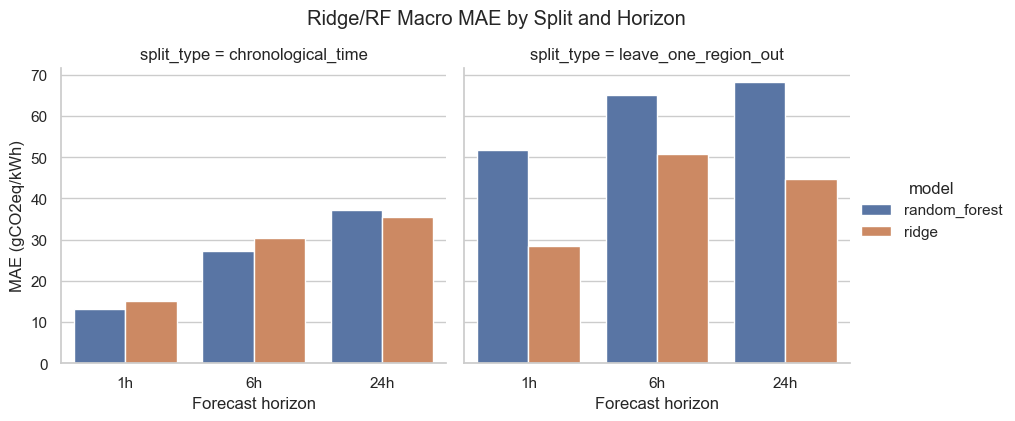

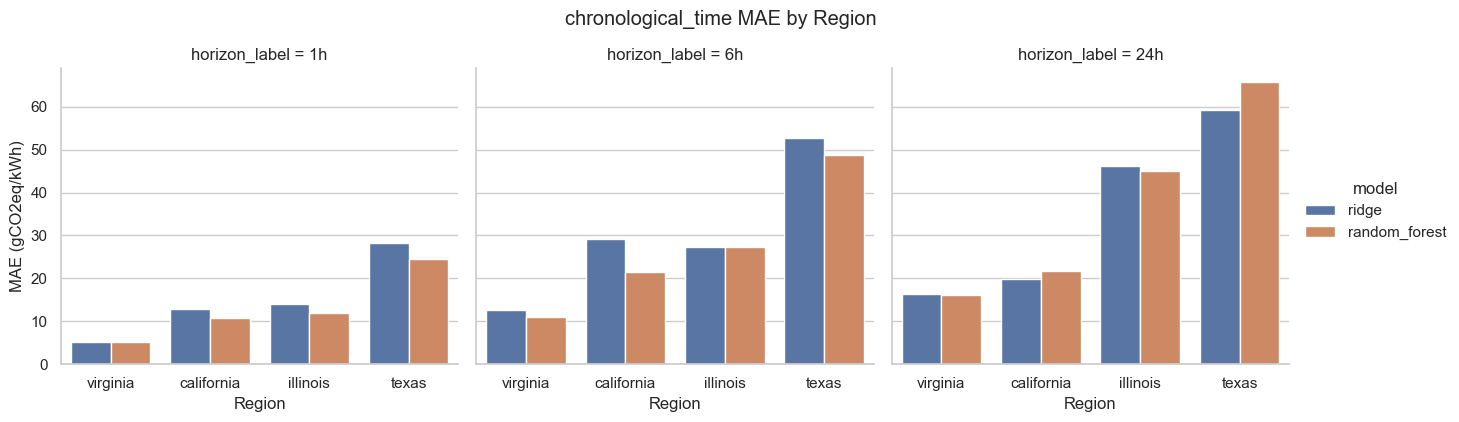

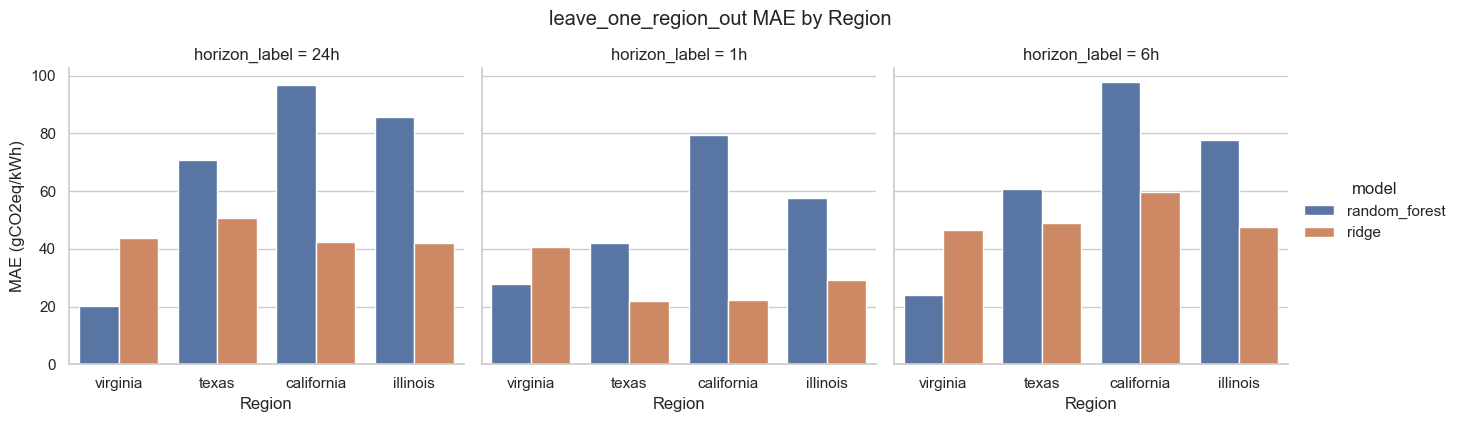

In [ ]:
macro = results_df[results_df["region"] == "macro_average"].copy()
macro["horizon_label"] = macro["horizon"].astype(str) + "h"

#setting up parameters for consistent visualization
g = sns.catplot(
    data=macro,
    x="horizon_label",
    y="MAE",
    hue="model",
    col="split_type",
    kind="bar",
    height=4,
    aspect=1.1,
)
g.fig.suptitle("Ridge/RF Macro MAE by Split and Horizon", y=1.05)
g.set_axis_labels("Forecast horizon", f"MAE ({UNIT})")
plt.show()

#generating all graphs
for split_type in ["chronological_time", "leave_one_region_out"]:
    viz = results_df[(results_df["split_type"] == split_type) & (results_df["region"] != "macro_average")].copy()
    viz["horizon_label"] = viz["horizon"].astype(str) + "h"
    g = sns.catplot(
        data=viz,
        x="region",
        y="MAE",
        hue="model",
        col="horizon_label",
        kind="bar",
        height=4,
        aspect=1.1,
    )
    g.fig.suptitle(f"{split_type} MAE by Region", y=1.05)
    g.set_axis_labels("Region", f"MAE ({UNIT})")
    plt.show()


## Random Split Note

The earlier random 80/20 Ridge/RF split is no longer used for official results because it mixes nearby timestamps and regions across train/test. That setup can still be useful for quick debugging, but it does not test temporal or regional generalization.


## Random Forest Feature Importance Diagnostic

This uses one trained RF model from the leave-one-out regional 24h Virginia setup for a quick sanity check. It is not part of the official comparison.


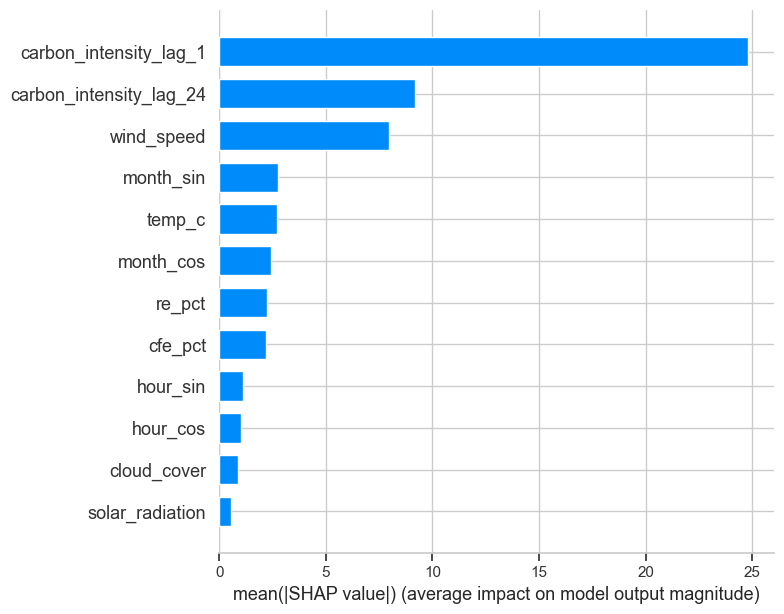

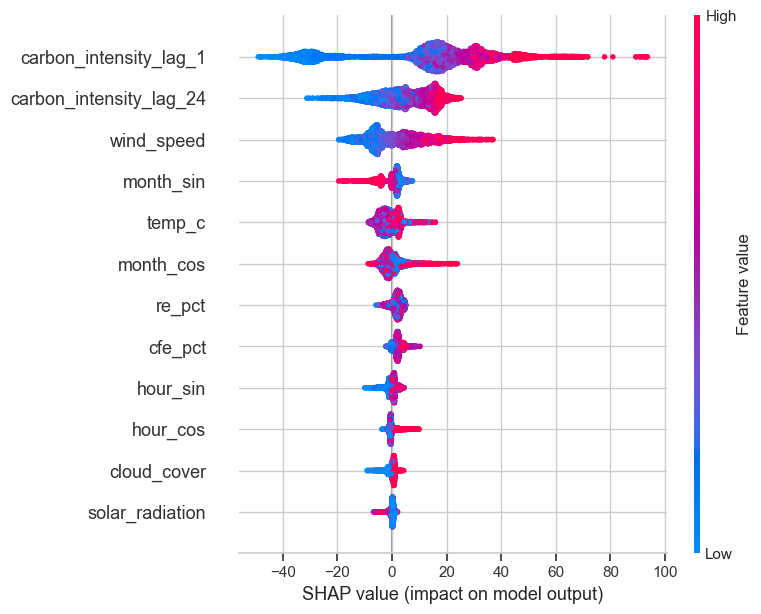

In [ ]:
import shap

#identify model
key = ("leave_one_region_out", "virginia", 24, "random_forest")
rf_model = trained_models.get(key)

#visualize SHAP
if rf_model is None:
    print("No RF model found for", key)
else:
    frame = make_forecast_frame(df, 24)
    test_frame = frame[frame["region"] == "virginia"].copy()
    X_test = test_frame[base_features]

    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test)

    shap.summary_plot(shap_values, X_test, feature_names=base_features, plot_type="bar", max_display=12)
    shap.summary_plot(shap_values, X_test, feature_names=base_features, max_display=12)